--- Data Overview ---


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,MONITOR,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,PHONE,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,TABLET,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,CHAIR,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,PRINTER,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04



--- Missing Values Check ---
OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

--- Summary Statistics ---


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


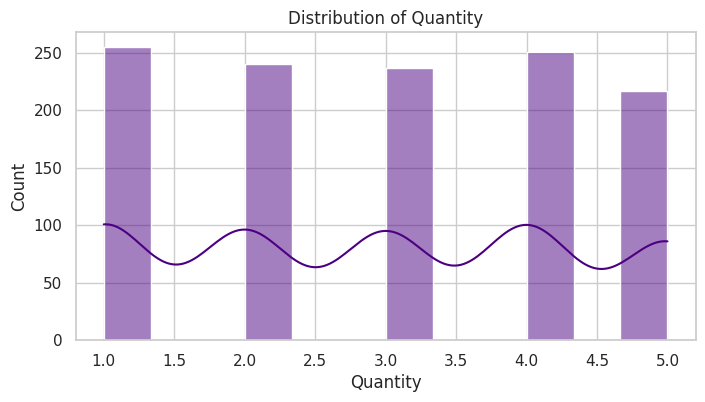

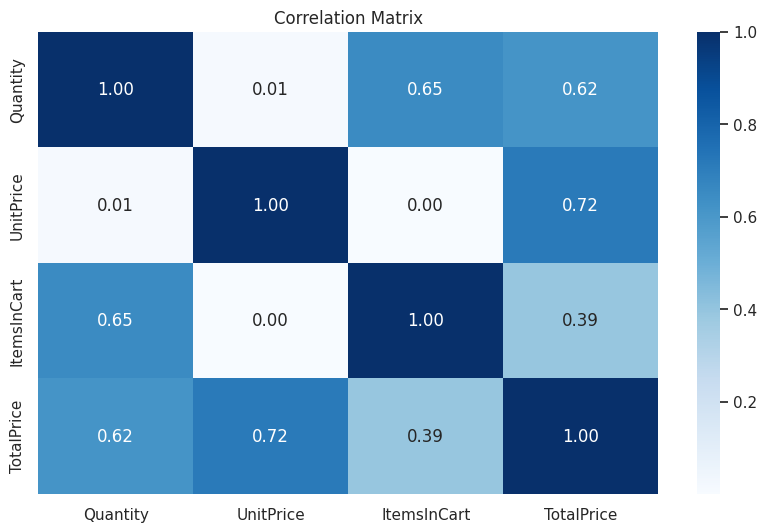

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Load Data (Make sure filename matches your uploaded CSV)
df = pd.read_csv("clean_dataset.csv")

# ---------------------------------------------------------
# STEP 1: Basic Structure & Inspection
# ---------------------------------------------------------
print("--- Data Overview ---")
display(df.head())

print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# ---------------------------------------------------------
# STEP 2: Data Cleaning
# ---------------------------------------------------------
df = df.drop_duplicates()

num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
  df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=["object"]).columns
for col in cat_cols:
  df[col] = df[col].fillna("Unknown")

# ---------------------------------------------------------
# STEP 3: Summary Statistics
# ---------------------------------------------------------
print("\n--- Summary Statistics ---")
display(df.describe())

# ---------------------------------------------------------
# STEP 4: Visualizations
# ---------------------------------------------------------
if len(num_cols) > 0:
  plt.figure(figsize=(8, 4))
  sns.histplot(df[num_cols[0]], kde=True, color="indigo")
  plt.title(f"Distribution of {num_cols[0]}")
  plt.savefig("distribution_plot.png", bbox_inches="tight")
  plt.show()

  plt.figure(figsize=(10, 6))
  sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
  plt.title("Correlation Matrix")
  plt.savefig("correlation_matrix.png", bbox_inches="tight")
  plt.show()
